# Vibes Signal Testing

In [19]:
%load_ext autoreload
%autoreload 2

from nasdaq_membership_matrix import get_nasdaq_membership_matrix
import pandas as pd 


start = pd.Timestamp("2020-01-01")
end = pd.Timestamp("2025-12-31")

data = get_nasdaq_membership_matrix(start, end)

## <a id="vibes data"> Vibes Data (Obvious survivorship bias)

In [47]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO

# Requested reference date
as_of_date = pd.Timestamp("2026-05-04")

def load_nasdaq100_tickers():
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        )
    }

    # Primary source: Wikipedia NASDAQ-100 constituents table
    wiki_url = "https://en.wikipedia.org/wiki/Nasdaq-100"
    r = requests.get(wiki_url, headers=headers, timeout=30)
    r.raise_for_status()
    tables = pd.read_html(StringIO(r.text))

    constituents = None
    for t in tables:
        cols = [str(c).strip() for c in t.columns]
        if "Ticker" in cols and ("Company" in cols or "GICS Sector" in cols):
            constituents = t.copy()
            break

    if constituents is None:
        # Fallback source (same index membership, alternate page)
        fallback_url = "https://www.slickcharts.com/nasdaq100"
        r2 = requests.get(fallback_url, headers=headers, timeout=30)
        r2.raise_for_status()
        fallback_tables = pd.read_html(StringIO(r2.text))
        candidates = [t for t in fallback_tables if "Symbol" in [str(c).strip() for c in t.columns]]
        if not candidates:
            raise ValueError("Could not find NASDAQ-100 constituents table from sources.")
        constituents = candidates[0].rename(columns={"Symbol": "Ticker"})

    constituents.columns = [str(c).strip() for c in constituents.columns]

    # Some sources include two share classes for one company; trim to 100 companies when possible.
    if len(constituents) > 100 and "Company" in constituents.columns:
        constituents = constituents.drop_duplicates(subset=["Company"], keep="first")

    tickers = (
        constituents["Ticker"]
        .astype(str)
        .str.strip()
        .str.replace(".", "-", regex=False)
        .drop_duplicates()
        .tolist()
    )

    if len(tickers) < 100:
        raise ValueError(f"Only found {len(tickers)} NASDAQ-100 tickers.")
    if len(tickers) > 100:
        tickers = tickers[:100]

    return tickers

tickers = load_nasdaq100_tickers()

# Fetch adjusted close prices from 2025-01-01
start_date = "2025-01-01"
adj_close = yf.download(
    tickers,
    start=start_date,
    auto_adjust=False,
    progress=False,
    threads=True,
)["Adj Close"]

print(f"As-of date: {as_of_date.date()}")
print(f"Constituents fetched: {len(tickers)}")
print(adj_close.head())

data = adj_close.dropna()

As-of date: 2026-05-04
Constituents fetched: 100
Ticker            AAPL        ABNB        ADBE         ADI         ADP  \
Date                                                                     
2025-01-02  242.525177  131.479996  441.000000  207.272095  281.047150   
2025-01-03  242.037827  135.710007  430.570007  211.214539  283.026489   
2025-01-06  243.668930  135.199997  431.179993  213.793793  278.601929   
2025-01-07  240.894073  131.289993  422.630005  211.704895  279.834259   
2025-01-08  241.381409  130.800003  419.579987  216.186722  283.220612   

Ticker            ADSK        AEP        ALNY        AMAT         AMD  ...  \
Date                                                                   ...   
2025-01-02  293.320007  88.146843  233.619995  162.043793  120.629997  ...   
2025-01-03  294.059998  88.252304  234.279999  168.164795  125.370003  ...   
2025-01-06  292.510010  86.593681  233.149994  175.502121  129.550003  ...   
2025-01-07  290.820007  86.737503  235.949

# Vibes Signals:

## Signal 1: 20 Day Momentum. 

The 20 day Momentum formula is calculated using 

$$ M_{t,20} = \frac{P_t - P_{t - 20}}{P_{t - 20}}$$

In [50]:
import numpy as np 
import matplotlib.pyplot as plt

In [51]:
momentum_data = data.pct_change(periods=20).dropna()
returns_data = data.pct_change(periods=1).reindex(momentum_data.index)

# Calculating the correlation
momentum_data = momentum_data[:-1]
returns_data = returns_data[1:]

IC summary
Mean IC: -0.004346
IC t-stat: -0.294
IC observations: 292


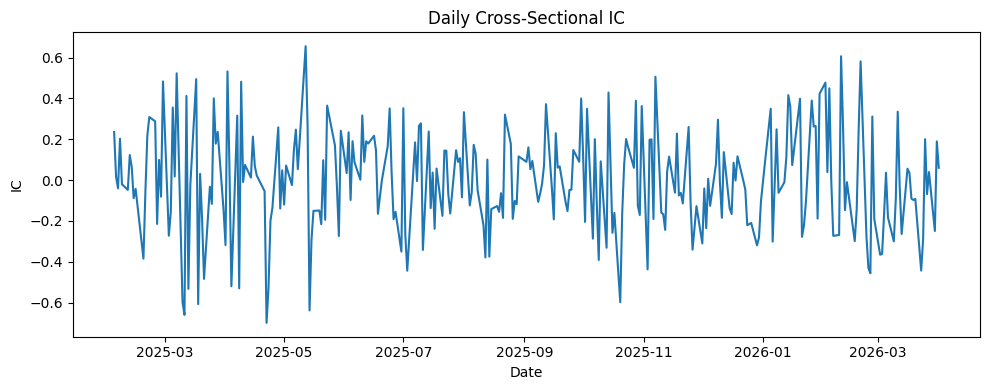

In [52]:
ic_values = []
ic_dates = []

for i in range(len(momentum_data.index)):
    x = momentum_data.iloc[i]
    y = returns_data.iloc[i]
    valid = x.notna() & y.notna()
    if valid.sum() >= 10:
        # Spearman IC = Pearson correlation of ranks
        ic = x[valid].rank().corr(y[valid].rank(), method="pearson")
        ic_values.append(ic)
        ic_dates.append(momentum_data.index[i])

ic_series = pd.Series(ic_values, index=ic_dates, name="IC")

ic_mean = ic_series.mean()
ic_std = ic_series.std(ddof=1)
ic_tstat = ic_mean / (ic_std / np.sqrt(len(ic_series)))

print("IC summary")
print(f"Mean IC: {ic_mean:.6f}")
print(f"IC t-stat: {ic_tstat:.3f}")
print(f"IC observations: {len(ic_series)}")

plt.figure(figsize=(10, 4))
plt.plot(ic_series.index, ic_series.values)
plt.title("Daily Cross-Sectional IC")
plt.xlabel("Date")
plt.ylabel("IC")
plt.tight_layout()
plt.show()

Latest rolling annualised Sharpe (63d):
2026-03-27   -0.032932
2026-03-30   -0.109914
2026-03-31   -0.051122
2026-04-01    0.263166
2026-04-02    0.344156
Name: strategy_return, dtype: float64


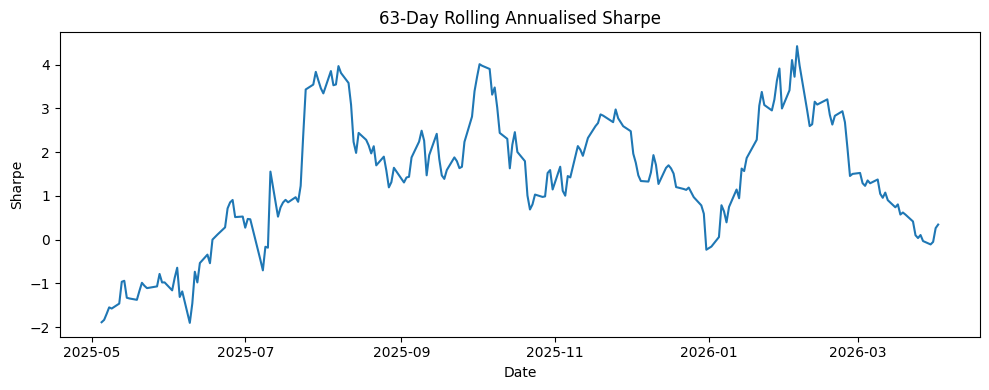

In [60]:
# Long top 10%, short bottom 10% with equal weightings.

percentage = 0.1
tickers_selected = int(percentage * len(momentum_data.columns))
portfolio_returns = []
portfolio_returns_dates = []

dates = returns_data.index

for i in range(len(momentum_data)):
    ranks = momentum_data.iloc[i].rank().sort_values(ascending=False)
    long_tickers = ranks[0:tickers_selected].index
    short_tickers = ranks[-tickers_selected:].index
    long_returns = returns_data.loc[dates[i], long_tickers].mean()
    short_returns = -returns_data.loc[dates[i], short_tickers].mean()
    total_returns = long_returns + short_returns
    portfolio_returns.append(total_returns)
    portfolio_returns_dates.append(dates[i])

returns_series = pd.Series(portfolio_returns, index=portfolio_returns_dates, name="strategy_return")

def rolling_annualised_sharpe(returns: pd.Series, window: int = 63, periods_per_year: int = 252):
    returns = returns.dropna().sort_index()
    if returns.empty:
        raise ValueError("No returns available to calculate Sharpe ratio.")

    def _sharpe(x: pd.Series):
        std = x.std(ddof=1)
        if std == 0 or np.isnan(std):
            return np.nan
        return np.sqrt(periods_per_year) * x.mean() / std

    # Rolling window Sharpe via rolling().apply()
    return returns.rolling(window=window, min_periods=window).apply(_sharpe, raw=False)

rolling_sharpe_3m = rolling_annualised_sharpe(returns_series, window=63)
print("Latest rolling annualised Sharpe (63d):")
print(rolling_sharpe_3m.dropna().tail())

plt.figure(figsize=(10, 4))
plt.plot(rolling_sharpe_3m.index, rolling_sharpe_3m.values)
plt.title("63-Day Rolling Annualised Sharpe")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.tight_layout()
plt.show()